# Notebook 2: Descomposición factor común / componente idiosincrático

Este notebook descompone los retornos de cada activo en tres piezas:

$$r_{i,t} = \beta_{mkt,i} \cdot f_{mkt,t} + \beta_{sec,i} \cdot f_{sec(s)\setminus i,t} + \epsilon_{i,t}$$

- **Factor de mercado**: retorno medio de los activos del universo cada día.
- **Factor sectorial (leave-one-out, ponderado por correlación)**: media
  ponderada de los retornos de los activos del mismo sector cada día,
  **excluyendo al propio activo**, donde el peso de cada compañero es
  proporcional a su correlación histórica con el activo.
- **Componente idiosincrático**: lo que queda tras restar ambos factores (específico de cada empresa).

Esta descomposición es la base para poder simular después escenarios
controlados (Notebook 3): perturbar un factor concreto (p.ej. "más
volatilidad en banca") o un componente idiosincrático concreto (p.ej.
"shock negativo solo en un banco") sin afectar al resto del universo.

**Nota metodológica — media simple vs. PCA:** para calcular el factor de
mercado usamos la media aritmética simple (mismo peso para todos los
activos del universo). El PCA encontraría automáticamente la combinación
de activos que más varianza conjunta explica, pero el resultado es menos
interpretable (el "primer componente principal" no siempre coincide con
la idea intuitiva de "el mercado"). La media simple es más transparente
para poder justificar con claridad qué significa "simular un shock en el
factor mercado". El PCA queda anotado como posible extensión futura.

**Historial de iteraciones del factor sectorial:**

1. **Versión inicial (media simple, incluyendo al propio activo):** PCG
   —el activo con el evento idiosincrático más extremo del dataset
   (bancarrota, caída de -74% en un día)— salía con R²=0.885, el segundo
   más alto del universo. Causa: el activo aparecía a la vez como variable
   a explicar y como parte de la variable explicativa (autocontaminación),
   más fuerte cuanto menor el sector.

2. **Leave-one-out equiponderado (universo de 25 activos, mínimo 2 por
   sector):** corrigió la autocontaminación (PCG bajó a R²=0.136), pero en
   sectores de exactamente 2 activos el factor de cada uno se reducía a la
   serie cruda de su único compañero, generando betas sectoriales negativos
   poco intuitivos en varios activos (CSX, F, AAL, TSLA).

3. **Leave-one-out equiponderado (universo ampliado a 30 activos, mínimo 3
   por sector):** corrigió el problema para AAL y TSLA (betas pasaron a
   ser positivos y razonables), pero no para CSX ni F. Causa identificada:
   la clasificación GICS agrupa bajo el mismo sector empresas con
   comportamientos bursátiles distintos (Industrials mezcla aerolíneas
   —AAL, DAL— con una ferroviaria —CSX—; Consumer Discretionary mezcla
   growth stocks —TSLA, AMZN— con un fabricante de coches tradicional —F).
   Ampliar el número de activos no resuelve esta heterogeneidad de fondo.

4. **Leave-one-out ponderado por correlación (versión actual):** en lugar
   de dar el mismo peso a todos los compañeros de sector, se pondera cada
   uno según su correlación histórica con el activo que se está
   explicando. Así, para CSX, DAL/AAL (más parecidas entre sí que a CSX)
   pesan menos que si fuera un promedio simple, y el factor se adapta a la
   heterogeneidad real dentro del sector. Las correlaciones negativas se
   recortan a 0 (un compañero anticorrelacionado no resta peso, solo no
   contribuye); si todos los compañeros tienen correlación negativa, se
   usa peso igual como salvaguarda.

Una alternativa metodológicamente más robusta y sin este tipo de
compromisos, estándar en modelos de factores profesionales (Fama-French,
BARRA), sería usar **ETFs sectoriales externos** (p.ej. XLF, XLE) como
factor, en lugar de construirlo a partir de los propios activos del
universo. No se implementa aquí por requerir una fuente de datos adicional
a validar; queda anotada como línea de trabajo futuro.

In [1]:
import sys
sys.path.append('..')

import json
import pandas as pd
import matplotlib.pyplot as plt

from src.factors.decomposition import (
    compute_market_factor,
    compute_sector_factors,
    compute_sector_factors_loo,
    compute_sector_factors_loo_weighted,
    decompose_universe,
    reconstruct_returns,
)

c:\Users\Miriamdbg\Desktop\MIAX\Tareas\Tarea 17 Generativos\miax-b5t1\notebooks\..\src\factors\decomposition.py:12: SyntaxWarning: invalid escape sequence '\i'
  r_{i,t} = beta_mkt_i * f_mkt,t + beta_sec_i * f_sec(s)\i,t + eps_{i,t}


## 1. Cargar los retornos y el mapa de sectores (Notebook 1)

In [2]:
returns = pd.read_parquet("../data/processed/returns_daily.parquet")
returns.head()

symbol,AAL,AAPL,AMD,AMZN,B,BAC,BMY,C,CLF,CSX,...,NEE,NVDA,OXY,PCG,PFE,RIG,TSLA,WFC,WMT,XOM
date,,,,,,,,,,,,,,,,,,,,,
2015-01-05,-0.000649,-0.028576,-0.011215,-0.020731,-0.000917,-0.029481,-0.015751,-0.032022,-0.075312,-0.027430,...,-0.010648,-0.017034,-0.037778,0.016732,-0.005441,-0.073259,-0.042950,-0.027805,-0.002915,-0.027743
2015-01-06,-0.015620,0.000094,-0.011342,-0.023098,0.033382,-0.030376,-0.001708,-0.035839,-0.032739,-0.040667,...,0.003877,-0.030787,-0.008535,-0.001476,0.008309,-0.022824,0.005648,-0.021085,0.007676,-0.005330
2015-01-07,-0.000566,0.013925,-0.019195,0.010544,-0.013399,0.004734,0.012912,0.009227,0.080652,0.013053,...,0.009112,-0.002870,0.000130,0.007908,0.013593,-0.009768,-0.001563,0.005934,0.026186,0.010082
2015-01-08,0.012187,0.037702,0.011561,0.006813,-0.028274,0.020451,0.024676,0.014936,0.069188,0.015790,...,0.006060,0.037189,0.008791,0.012560,0.020203,-0.001842,-0.001589,0.021896,0.020886,0.016508
2015-01-09,-0.031040,0.001072,0.007634,-0.011818,0.016514,-0.018092,-0.006609,-0.022587,-0.024863,-0.002033,...,-0.008869,0.004020,-0.001933,0.009900,0.004605,-0.010504,-0.018957,-0.016567,-0.012457,-0.001411


In [3]:
with open("../data/processed/asset_sectors.json") as f:
    sector_map = json.load(f)

assert set(sector_map.keys()) == set(returns.columns), "El mapa de sector no coincide con los activos del dataset"
sector_map

{'BAC': 'Financials',
 'WFC': 'Financials',
 'C': 'Financials',
 'HBAN': 'Financials',
 'KEY': 'Financials',
 'XOM': 'Energy',
 'KMI': 'Energy',
 'RIG': 'Energy',
 'OXY': 'Energy',
 'NVDA': 'Information Technology',
 'AAPL': 'Information Technology',
 'AMD': 'Information Technology',
 'PFE': 'Health Care',
 'BMY': 'Health Care',
 'MRK': 'Health Care',
 'TSLA': 'Consumer Discretionary',
 'F': 'Consumer Discretionary',
 'AMZN': 'Consumer Discretionary',
 'AAL': 'Industrials',
 'CSX': 'Industrials',
 'DAL': 'Industrials',
 'WMT': 'Consumer Staples',
 'KO': 'Consumer Staples',
 'MO': 'Consumer Staples',
 'PCG': 'Utilities',
 'NEE': 'Utilities',
 'EXC': 'Utilities',
 'FCX': 'Materials',
 'B': 'Materials',
 'CLF': 'Materials'}

## 2. Descomposición completa del universo

**Nota metodológica — ortogonalización del factor sectorial:** el factor de
mercado y los factores sectoriales están correlacionados entre sí (el mercado
incluye a los sectores), lo que puede hacer que una regresión conjunta
reparta el efecto de forma poco intuitiva entre `beta_market` y `beta_sector`.
Para evitarlo, antes de la regresión por activo "purificamos" cada factor
sectorial (ya leave-one-out ponderado) respecto al mercado. Esto ya está
implementado dentro de `decompose_universe` (ver `src/factors/decomposition.py`).

`decompose_universe(..., weighted=True)` usa la versión ponderada por
correlación; `weighted=False` usaría la equiponderada, dejada disponible
para comparación si se quiere reproducir la iteración anterior.

In [4]:
decomposition = decompose_universe(returns, sector_map, weighted=True)

market_factor = decomposition["market_factor"]
sector_factors_raw = decomposition["sector_factors_raw"]  # por sector, sin LOO, solo para gráficas
sector_factors = decomposition["sector_factors"]  # LOO ponderado y ortogonalizado, por símbolo
betas = decomposition["betas"]
idiosyncratic = decomposition["idiosyncratic"]

betas.sort_values("r_squared", ascending=False)

,sector,beta_market,beta_sector,r_squared
symbol,,,,
BAC,Financials,1.115007,0.782893,0.822262
C,Financials,1.219416,0.678316,0.783453
HBAN,Financials,1.147768,0.946341,0.777768
KEY,Financials,1.364282,1.092293,0.777672
WFC,Financials,1.076418,0.736935,0.732943
DAL,Industrials,1.281393,0.797131,0.725660
AAL,Industrials,1.453267,1.254635,0.671465
XOM,Energy,0.870303,0.347795,0.600971
OXY,Energy,1.450393,0.802808,0.578885


## 2b. Comparación rápida: equiponderado vs. ponderado por correlación

Foco en los 4 activos donde el equiponderado daba betas sectoriales poco
intuitivos (CSX, F, AAL, TSLA), para comprobar si la ponderación por
correlación mejora el caso que seguía sin resolverse (CSX, F).

In [5]:
decomposition_equal = decompose_universe(returns, sector_map, weighted=False)
betas_equal = decomposition_equal["betas"]

comparison = pd.DataFrame({
    "beta_sector_equiponderado": betas_equal.loc[["CSX", "F", "AAL", "TSLA"], "beta_sector"],
    "beta_sector_ponderado_corr": betas.loc[["CSX", "F", "AAL", "TSLA"], "beta_sector"],
})
comparison

,beta_sector_equiponderado,beta_sector_ponderado_corr
symbol,,
CSX,-0.056458,-0.056364
F,-0.057685,-0.053576
AAL,1.266010,1.254635
TSLA,0.371145,0.420114


## 3. Visualización de los factores

Los factores sectoriales que se grafican aquí son la versión "cruda" (por
sector, sin leave-one-out ni ponderación), útil para ver la evolución
general de cada sector. La regresión de la sección 2 usa la versión LOO
ponderada por correlación, no esta.

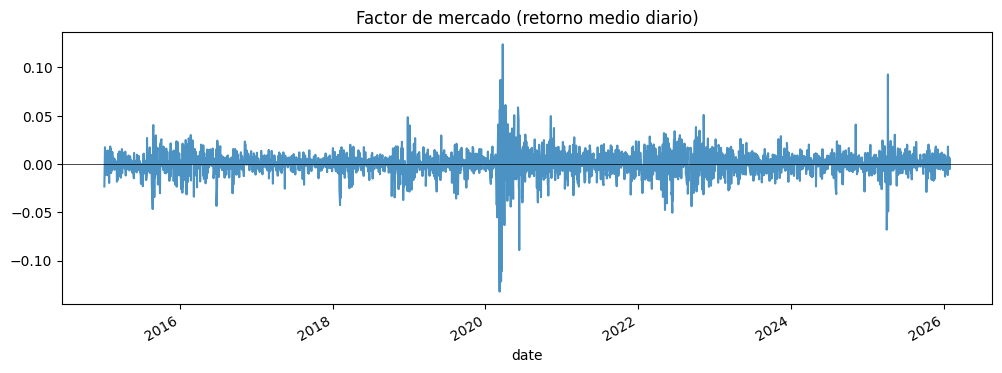

In [6]:
market_factor.plot(figsize=(12, 4), title="Factor de mercado (retorno medio diario)", alpha=0.8)
plt.axhline(0, color="black", linewidth=0.5)
plt.show()

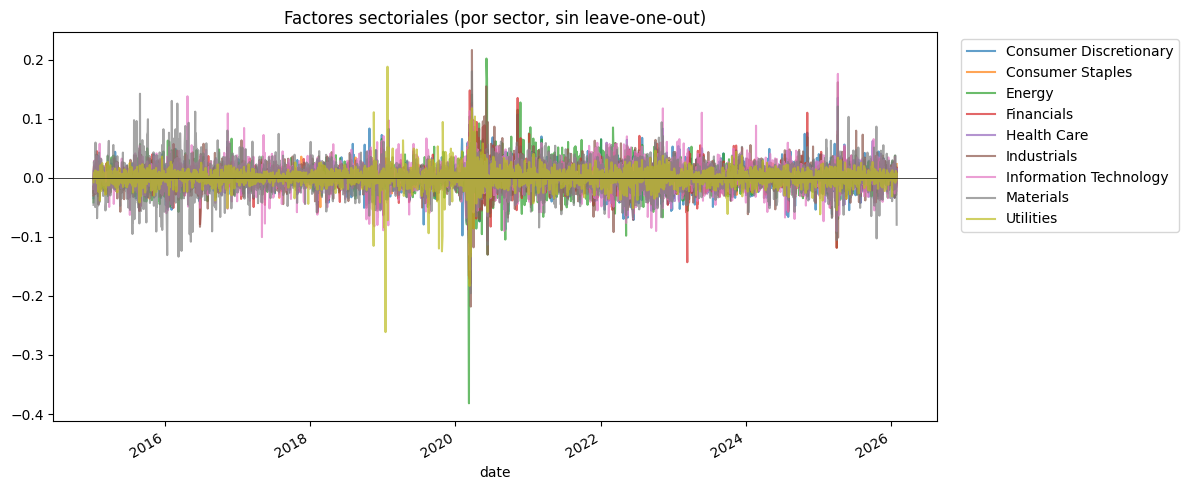

In [7]:
sector_factors_raw.plot(figsize=(12, 5), title="Factores sectoriales (por sector, sin leave-one-out)", alpha=0.7)
plt.axhline(0, color="black", linewidth=0.5)
plt.legend(bbox_to_anchor=(1.02, 1), loc="upper left")
plt.tight_layout()
plt.show()

## 4. Calidad de la descomposición (R²)

Cuanto mayor el R², más explica el modelo de factores el movimiento del
activo. PCG debería seguir entre los R² más bajos (dominado por su evento
propio); revisad también si CSX y F ya tienen beta_sector positivo tras la
ponderación por correlación (ver comparación en la sección 2b).

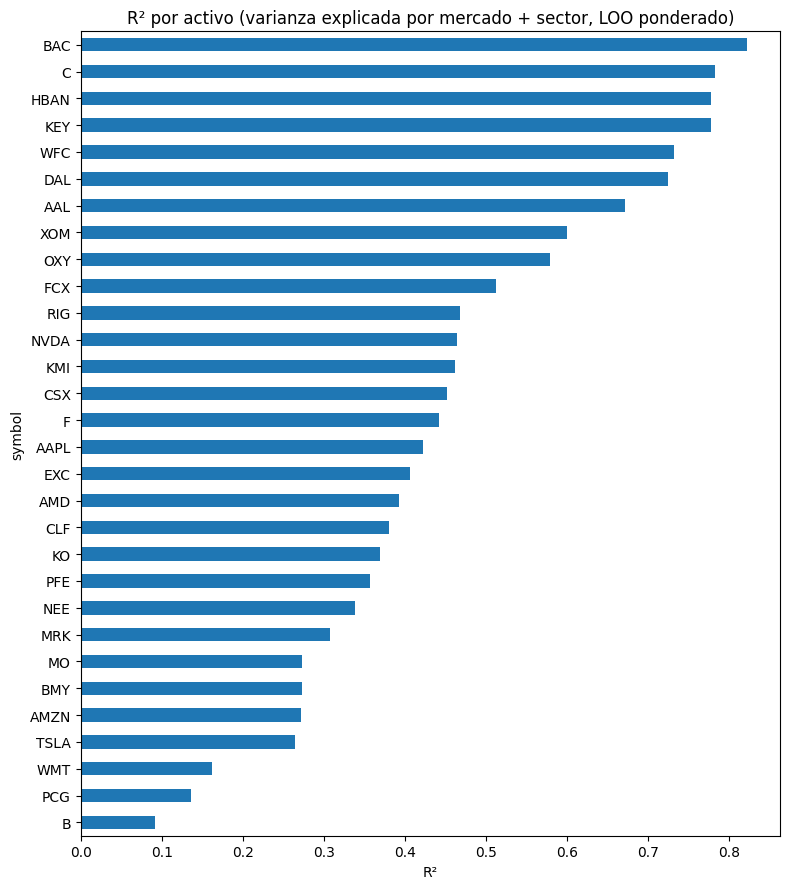

In [8]:
betas["r_squared"].sort_values().plot(
    kind="barh", figsize=(8, 9), title="R² por activo (varianza explicada por mercado + sector, LOO ponderado)"
)
plt.xlabel("R²")
plt.tight_layout()
plt.show()

## 5. Comprobación de consistencia: reconstrucción

Si sumamos los tres componentes (mercado, sector LOO ponderado y
ortogonalizado, idiosincrático) con sus betas correspondientes, deberíamos
recuperar (aprox.) los retornos originales.

El umbral se fija en `1e-6`: con `float64` las diferencias residuales de una
regresión por mínimos cuadrados quedan en torno a `1e-9`/`1e-17`, pero un
umbral más laxo evita falsos positivos por acumulación de redondeo.

In [9]:
reconstructed = reconstruct_returns(market_factor, sector_factors, idiosyncratic, betas)

max_diff = (returns[reconstructed.columns] - reconstructed).abs().max().max()
print(f"Diferencia máxima entre original y reconstruido: {max_diff:.2e}")
assert max_diff < 1e-6, "La reconstrucción no coincide con los retornos originales"

Diferencia máxima entre original y reconstruido: 2.78e-17


## 6. Guardado de los componentes

Guardamos cada pieza por separado: el factor de mercado, los factores
sectoriales leave-one-out ponderados y ortogonalizados (los usados en la
regresión y en la reconstrucción, indexados por símbolo), las betas de cada
activo, y los componentes idiosincráticos.

In [10]:
market_factor.to_frame().to_parquet("../data/processed/market_factor.parquet")
sector_factors.to_parquet("../data/processed/sector_factors.parquet")
betas.to_parquet("../data/processed/factor_betas.parquet")
idiosyncratic.to_parquet("../data/processed/idiosyncratic_returns.parquet")

print("Guardados en data/processed/: market_factor, sector_factors, factor_betas, idiosyncratic_returns")

Guardados en data/processed/: market_factor, sector_factors, factor_betas, idiosyncratic_returns


## 7. Conclusión

- Se descompuso cada uno de los 30 activos en factor de mercado + factor
  sectorial leave-one-out ponderado por correlación (ortogonalizado
  respecto al mercado) + componente idiosincrático.
- El mapa de sector se carga automáticamente desde
  `data/processed/asset_sectors.json`, generado en el Notebook 1.
- La reconstrucción confirma que la descomposición es correcta y no pierde
  información.
- **Cuatro iteraciones del factor sectorial** (ver nota metodológica al
  inicio del notebook): (1) media simple con autocontaminación → (2)
  leave-one-out equiponderado, sectores de 2 → (3) leave-one-out
  equiponderado, sectores de 3 → (4) leave-one-out ponderado por
  correlación. Las tres primeras corrigieron problemas reales y medibles
  (autocontaminación de PCG, betas muy negativos en AAL/TSLA con sectores
  de 2 activos).
- **La cuarta iteración (ponderación por correlación) no mejoró CSX ni F:**
  beta_sector pasó de -0.0565 a -0.0564 en CSX, y de -0.0577 a -0.0536 en F
  — una diferencia despreciable. Causa: la ponderación por correlación solo
  puede corregir el sesgo cuando los compañeros de sector tienen
  correlaciones claramente distintas entre sí con el activo en cuestión;
  en Industrials, CSX correlaciona de forma similar con AAL y con DAL, así
  que la ponderación acaba dando pesos casi iguales a ambos, igual que el
  promedio simple. Conclusión: estos betas pequeños y negativos no parecen
  un artefacto del método de cálculo, sino una característica real de
  estos dos activos concretos (tras controlar por mercado, no tienen una
  relación sectorial fuerte con sus compañeros) — se documentan como
  limitación conocida, no como un problema pendiente de arreglar. No se
  itera más sobre este punto: la magnitud es pequeña (comparar con betas
  de +0.78 a +1.25 en el resto de sectores cohesionados) y no compensa el
  tiempo frente al resto del proyecto (generativos, predictor, evaluación).
- Se documenta, como alternativa más robusta y sin este tipo de
  compromisos, el uso de ETFs sectoriales externos como línea de trabajo
  futuro.

**Siguiente paso (Notebook 3):** entrenar los 4 modelos generativos (ruido,
gaussiana ajustada, VAE, AR/GRU) para aprender a generar factor de mercado,
factores sectoriales y componentes idiosincráticos por separado, de forma
que se puedan perturbar de forma controlada y reconstruir escenarios
sintéticos condicionados.